In [2]:
import pandas as pd
import numpy as np
import sklearn
from sklearn import datasets

Загрузим датасет Iris из открытого источника по URL-ссылке с помощью библиотеки pandas. После загрузки данные сохраняются в таблицу data. Далее из набора данных выделяются признаки объектов — первые четыре столбца (длина и ширина чашелистика и лепестка), которые преобразуются в числовой массив X. Пятый столбец содержит названия видов ирисов, они сохраняются в переменную labels. Поскольку алгоритмы машинного обучения работают с числовыми значениями, текстовые названия классов преобразуются в числовые метки с помощью LabelEncoder. В результате получаем массив Y, содержащий закодированные классы растений, который будет использоваться при обучении модели классификации.

In [3]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"
data = pd.read_csv(url, header=None)
X = data.iloc[:,:4].to_numpy()
labels = data.iloc[:,4].to_numpy()
le = sklearn.preprocessing.LabelEncoder()
Y = le.fit_transform(labels)

In [4]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.50)

В scikit-learn реализованы три вида наивных байесовских классификаторов: GaussianNB, BernoulliNB и MultinomialNB. GaussianNB можно применить к любым непрерывным данным

Создадим модель наивного байесовского классификатора с использованием класса GaussianNB из библиотеки sklearn, который применяется для работы с непрерывными числовыми данными. Затем обучим модель на обучающей выборке X_train и y_train с помощью метода fit, после чего выполним предсказание классов для тестовой выборки X_test. Полученные результаты сохраняются в переменной y_pred. Далее вычисляется количество неверно классифицированных объектов путём сравнения истинных значений y_test и предсказаний модели. Также рассчитывается метрика accuracy, которая показывает долю правильно классифицированных объектов в тестовой выборке.

In [5]:
from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()
y_pred = gnb.fit(X_train, y_train).predict(X_test)
print((y_test != y_pred).sum()) # кол-во неверно предсказанных
gnb.score(X_test, y_test) # accuracy

4


0.9466666666666667

Просмотрим метрики с помощью sklearn.metrics

In [6]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Вычисляем аккуратность (accuracy)
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.9466666666666667

In [7]:
# Вычисляем точность
precision_weighted = precision_score(y_test, y_pred, average='weighted')
precision_weighted

0.9479545454545454

In [8]:
# Вычисляем полноту (recall)
recall_weighted = recall_score(y_test, y_pred, average='weighted')
recall_weighted

0.9466666666666667

In [9]:
# Вычисляем F-меру
f1_weighted = f1_score(y_test, y_pred, average='weighted')
f1_weighted

0.946367461430575

Зададим список значений size, который определяет различные размеры тестовой выборки — от 40% до 10%, что соответствует соотношению обучающей и тестовой выборок от 60:40 до 90:10. Далее создадим пустые списки accuracy, precision, recall и f1, в которые будут сохраняться значения соответствующих метрик качества классификации. В цикле для каждого значения размера тестовой выборки данные разделяются на обучающую и тестовую части с помощью train_test_split. После этого модель наивного байесовского классификатора обучается на обучающей выборке и выполняет предсказание для тестовой выборки. Для полученных предсказаний вычисляются метрики accuracy, precision, recall и F1-мера, которые добавляются в соответствующие списки для последующего анализа и построения графиков.

In [10]:
size=[0.40, 0.35, 0.30, 0.25, 0.20, 0.15, 0.10]

accuracy = []
precision = []
recall = []
f1 = []

for sz in size:
  X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=sz)
  y_pred = gnb.fit(X_train, y_train).predict(X_test)
  accuracy.append(accuracy_score(y_test, y_pred))
  precision.append(precision_score(y_test, y_pred, average='weighted'))
  recall.append(recall_score(y_test, y_pred, average='weighted'))
  f1.append(f1_score(y_test, y_pred, average='weighted'))

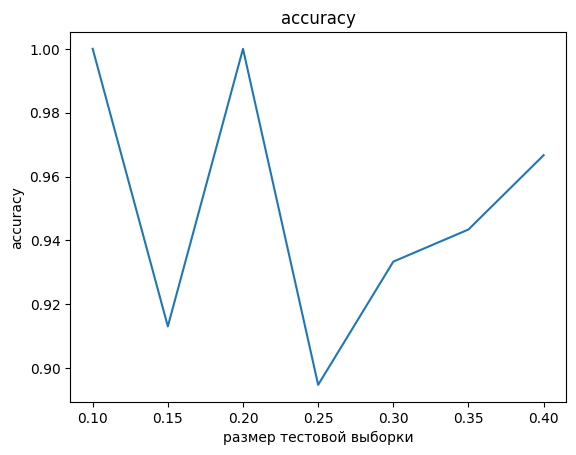

In [11]:
import matplotlib.pyplot  as plot
plot.plot(size,accuracy)
plot.title("accuracy")
plot.xlabel("размер тестовой выборки")
plot.ylabel("accuracy")
plot.show()

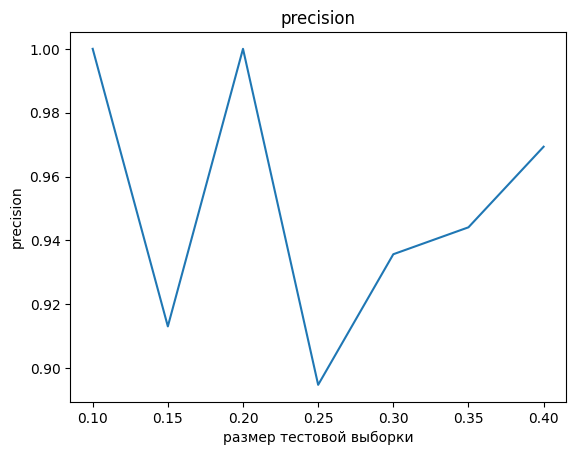

In [12]:
import matplotlib.pyplot  as plot
plot.plot(size,precision)
plot.title("precision")
plot.xlabel("размер тестовой выборки")
plot.ylabel("precision")
plot.show()

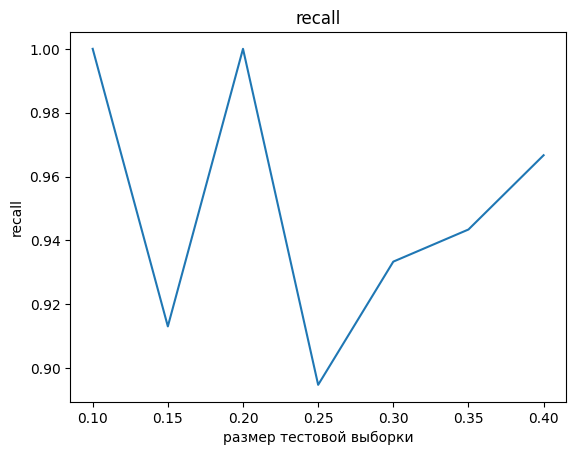

In [13]:
import matplotlib.pyplot  as plot
plot.plot(size,recall)
plot.title("recall")
plot.xlabel("размер тестовой выборки")
plot.ylabel("recall")
plot.show()

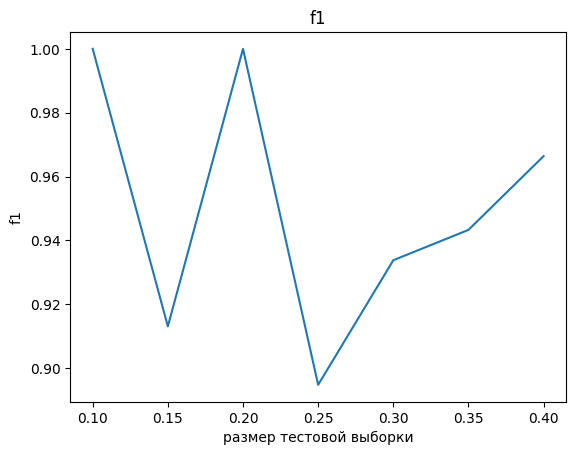

In [14]:
import matplotlib.pyplot  as plot
plot.plot(size,f1)
plot.title("f1")
plot.xlabel("размер тестовой выборки")
plot.ylabel("f1")
plot.show()

Все показатели примерно одинаковые, так что мы видим графии схожие между собой.

# Деревья решений

In [15]:
import pandas as pd
import numpy as np
import sklearn
from sklearn import datasets

Возьмем ту же задачу с классификацией Ирисов и решим ее при помощи деревьев

In [16]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"
data = pd.read_csv(url, header=None)
X = data.iloc[:,:4].to_numpy()
labels = data.iloc[:,4].to_numpy()
le = sklearn.preprocessing.LabelEncoder()
Y = le.fit_transform(labels)

Добавим к train_test_split параметр random_state, его значение укажет на одинаковое распределение элементов в разные выборки, что позволит сделать наш тест более точным

In [17]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.4, random_state=42)

Создадим модель классификации на основе дерева решений с использованием класса DecisionTreeClassifier из библиотеки sklearn. Затем обучим модель на обучающей выборке X_train и y_train с помощью метода fit. После обучения модель выполняет предсказание классов для тестовой выборки X_test, а результаты сохраняются в переменной y_pred. Далее производится сравнение предсказанных значений с истинными метками y_test, что позволяет определить количество неверно классифицированных объектов в тестовой выборке.

In [18]:
from sklearn import tree
clf = tree.DecisionTreeClassifier()
y_pred = clf.fit(X_train, y_train).predict(X_test)
print((y_test != y_pred).sum()) # число не верно предсказанных

1


Визуализируем дерево

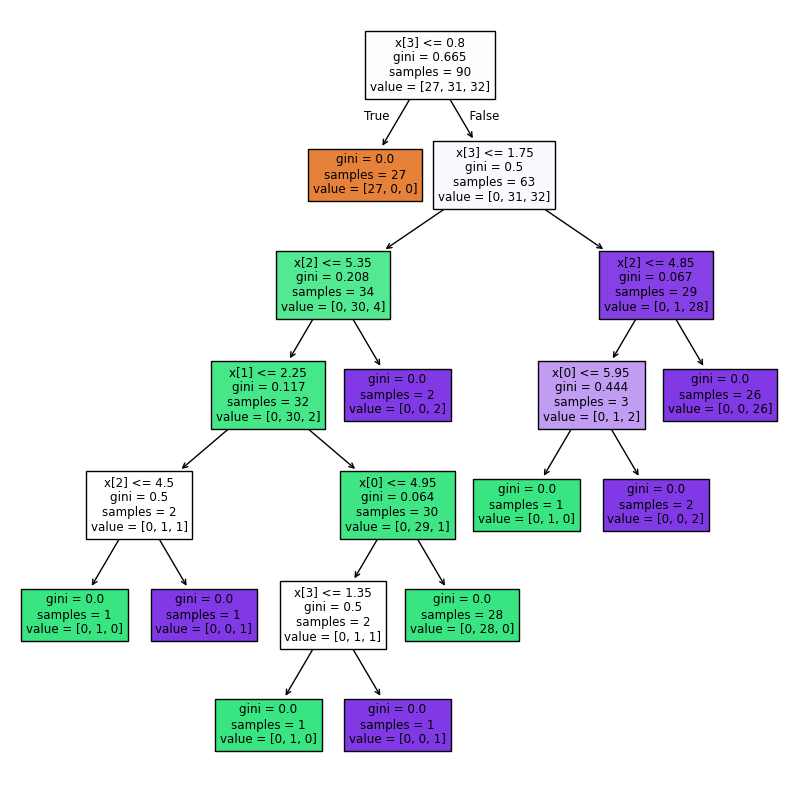

In [19]:
import matplotlib.pyplot as plt
plt.subplots(1,1,figsize = (10,10))
tree.plot_tree(clf, filled = True)
plt.show()

Посмотрим метрики с помощью classification_report

In [20]:
from sklearn.metrics import classification_report

# Оценка производительности модели
y_pred_info = clf.predict(X_test)
print("Classification Report:")
print(classification_report(y_test, y_pred_info))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       0.95      1.00      0.97        19
           2       1.00      0.94      0.97        18

    accuracy                           0.98        60
   macro avg       0.98      0.98      0.98        60
weighted avg       0.98      0.98      0.98        60



Добавим критерий выбора атрибута разбиения

Создадим две модели дерева решений с разными критериями выбора атрибута разбиения. Первая модель использует критерий Information Gain, который в библиотеке sklearn задаётся параметром criterion='entropy', и обучается на обучающей выборке. Вторая модель использует критерий индекса Джини, который задаётся параметром criterion='gini', и также обучается на тех же данных. Таким образом, можно сравнить влияние разных критериев разбиения на качество классификации и оценить их эффективность на тестовой выборке.

In [21]:
# Создание модели с критерием Information Gain
model_information_gain = tree.DecisionTreeClassifier(criterion='entropy')
model_information_gain.fit(X_train, y_train)

# Создание модели с критерием Gini
model_gini = tree.DecisionTreeClassifier(criterion='gini')
model_gini.fit(X_train, y_train)

DecisionTreeClassifier()

Визуализируем деревья

[Text(0.4444444444444444, 0.9285714285714286, 'x[2] <= 2.45\nentropy = 1.581\nsamples = 90\nvalue = [27, 31, 32]'),
 Text(0.3333333333333333, 0.7857142857142857, 'entropy = 0.0\nsamples = 27\nvalue = [27, 0, 0]'),
 Text(0.38888888888888884, 0.8571428571428572, 'True  '),
 Text(0.5555555555555556, 0.7857142857142857, 'x[3] <= 1.75\nentropy = 1.0\nsamples = 63\nvalue = [0, 31, 32]'),
 Text(0.5, 0.8571428571428572, '  False'),
 Text(0.3333333333333333, 0.6428571428571429, 'x[2] <= 5.35\nentropy = 0.523\nsamples = 34\nvalue = [0, 30, 4]'),
 Text(0.2222222222222222, 0.5, 'x[3] <= 1.45\nentropy = 0.337\nsamples = 32\nvalue = [0, 30, 2]'),
 Text(0.1111111111111111, 0.35714285714285715, 'entropy = 0.0\nsamples = 23\nvalue = [0, 23, 0]'),
 Text(0.3333333333333333, 0.35714285714285715, 'x[1] <= 2.6\nentropy = 0.764\nsamples = 9\nvalue = [0, 7, 2]'),
 Text(0.2222222222222222, 0.21428571428571427, 'x[0] <= 6.15\nentropy = 0.918\nsamples = 3\nvalue = [0, 1, 2]'),
 Text(0.1111111111111111, 0.0714285

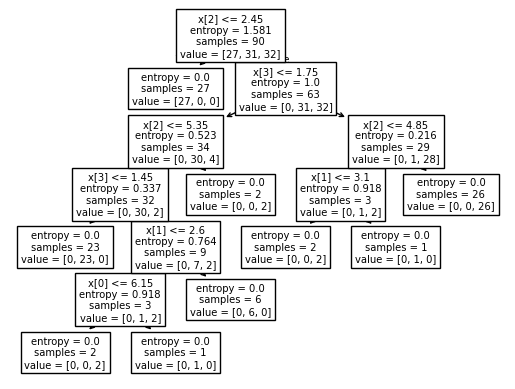

In [22]:
tree.plot_tree(model_information_gain)

[Text(0.5416666666666666, 0.9285714285714286, 'x[3] <= 0.8\ngini = 0.665\nsamples = 90\nvalue = [27, 31, 32]'),
 Text(0.4583333333333333, 0.7857142857142857, 'gini = 0.0\nsamples = 27\nvalue = [27, 0, 0]'),
 Text(0.5, 0.8571428571428572, 'True  '),
 Text(0.625, 0.7857142857142857, 'x[3] <= 1.75\ngini = 0.5\nsamples = 63\nvalue = [0, 31, 32]'),
 Text(0.5833333333333333, 0.8571428571428572, '  False'),
 Text(0.4166666666666667, 0.6428571428571429, 'x[2] <= 5.35\ngini = 0.208\nsamples = 34\nvalue = [0, 30, 4]'),
 Text(0.3333333333333333, 0.5, 'x[0] <= 4.95\ngini = 0.117\nsamples = 32\nvalue = [0, 30, 2]'),
 Text(0.16666666666666666, 0.35714285714285715, 'x[1] <= 2.45\ngini = 0.5\nsamples = 2\nvalue = [0, 1, 1]'),
 Text(0.08333333333333333, 0.21428571428571427, 'gini = 0.0\nsamples = 1\nvalue = [0, 1, 0]'),
 Text(0.25, 0.21428571428571427, 'gini = 0.0\nsamples = 1\nvalue = [0, 0, 1]'),
 Text(0.5, 0.35714285714285715, 'x[1] <= 2.25\ngini = 0.064\nsamples = 30\nvalue = [0, 29, 1]'),
 Text(0.

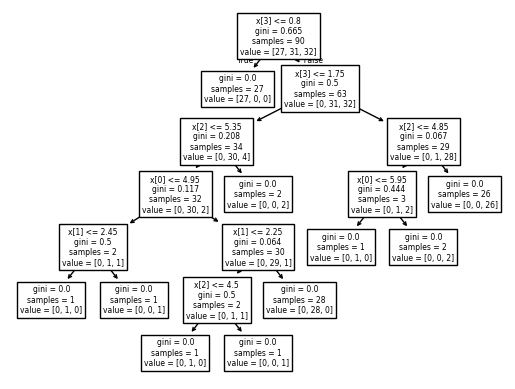

In [23]:
tree.plot_tree(model_gini)

In [24]:
from sklearn.metrics import classification_report

# Оценка производительности модели с критерием Information Gain
y_pred_information_gain = model_information_gain.predict(X_test)
print("Classification Report for Information Gain:")
print(classification_report(y_test, y_pred_information_gain))

# Оценка производительности модели с критерием Gini
y_pred_gini = model_gini.predict(X_test)
print("Classification Report for Gini:")
print(classification_report(y_test, y_pred_gini))

Classification Report for Information Gain:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       0.95      1.00      0.97        19
           2       1.00      0.94      0.97        18

    accuracy                           0.98        60
   macro avg       0.98      0.98      0.98        60
weighted avg       0.98      0.98      0.98        60

Classification Report for Gini:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       0.95      1.00      0.97        19
           2       1.00      0.94      0.97        18

    accuracy                           0.98        60
   macro avg       0.98      0.98      0.98        60
weighted avg       0.98      0.98      0.98        60



In [25]:
print(model_information_gain.score(X_test, y_test)) # accuracy
print(model_gini.score(X_test, y_test)) # accuracy

0.9833333333333333
0.9833333333333333


Для gain Изменим соотношение мощностей обучающей и тестовой выборок (от 60%:40% до 90%:10% с шагом 5%).

Зададим список значений размера тестовой выборки и создадим список для хранения значений точности (accuracy) для модели дерева решений с критерием Information Gain. Далее создаём модель DecisionTreeClassifier с параметром criterion='entropy', что соответствует использованию энтропии для вычисления информационного выигрыша. В цикле для каждого значения размера тестовой выборки выполняется разбиение данных на обучающую и тестовую выборки. Модель обучается на обучающих данных, после чего вычисляется её точность на тестовой выборке с помощью метода score, который возвращает значение метрики accuracy. Полученные обученные модели сохраняются в список для дальнейшего анализа и визуализации дерева решений.

In [26]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

size=[0.40, 0.35, 0.30, 0.25, 0.20, 0.15, 0.10]

accuracy_model_information_gain = []

tree_gain = []

# Создание модели с критерием Information Gain
model_information_gain = tree.DecisionTreeClassifier(criterion='entropy')

for sz in size:
  X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=sz, random_state=42)
  y_pred_gain = model_information_gain.fit(X_train, y_train)
  tree_gain.append(y_pred_gain)
  accuracy_model_information_gain.append(model_information_gain.score(X_test, y_test)) # accuracy

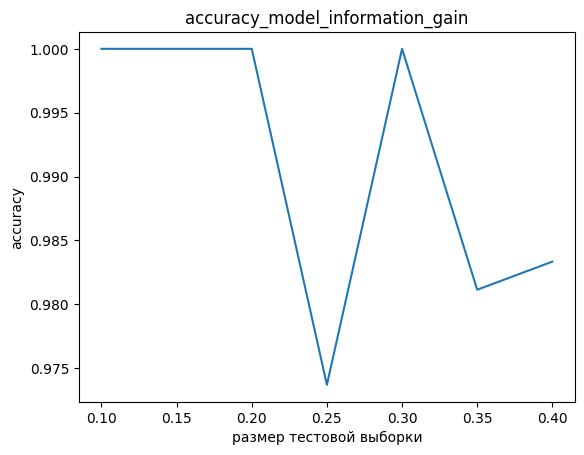

In [27]:
import matplotlib.pyplot  as plot
plot.plot(size,accuracy_model_information_gain)
plot.title("accuracy_model_information_gain")
plot.xlabel("размер тестовой выборки")
plot.ylabel("accuracy")
plot.show()

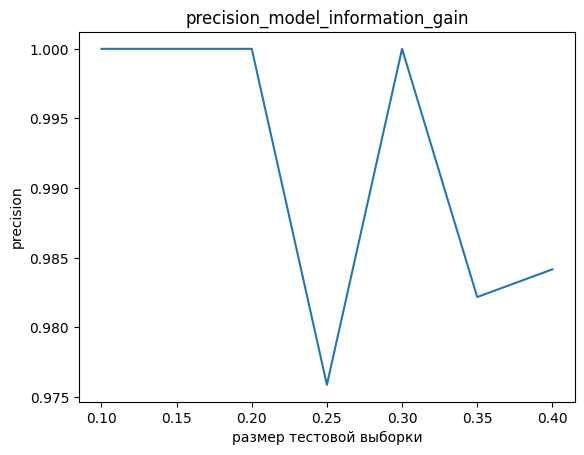

In [29]:
precision_model_information_gain = []

from sklearn.metrics import precision_score

for sz in size:
  X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=sz, random_state=42)
  y_pred = model_information_gain.fit(X_train, y_train).predict(X_test)
  precision_model_information_gain.append(precision_score(y_test, y_pred, average='weighted'))

import matplotlib.pyplot as plot
plot.plot(size, precision_model_information_gain)
plot.title("precision_model_information_gain")
plot.xlabel("размер тестовой выборки")
plot.ylabel("precision")
plot.show()

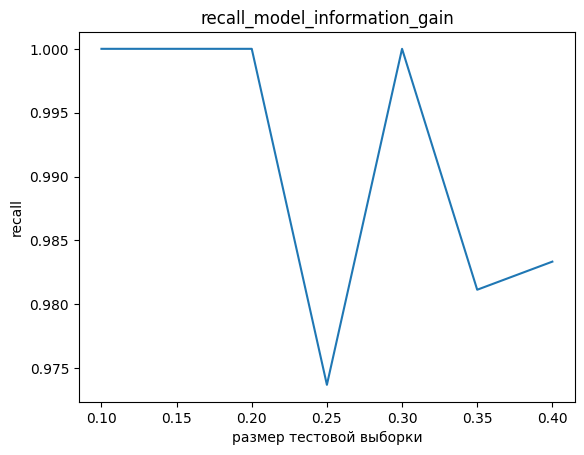

In [30]:
recall_model_information_gain = []

from sklearn.metrics import recall_score

for sz in size:
  X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=sz, random_state=42)
  y_pred = model_information_gain.fit(X_train, y_train).predict(X_test)
  recall_model_information_gain.append(recall_score(y_test, y_pred, average='weighted'))

import matplotlib.pyplot as plot
plot.plot(size, recall_model_information_gain)
plot.title("recall_model_information_gain")
plot.xlabel("размер тестовой выборки")
plot.ylabel("recall")
plot.show()

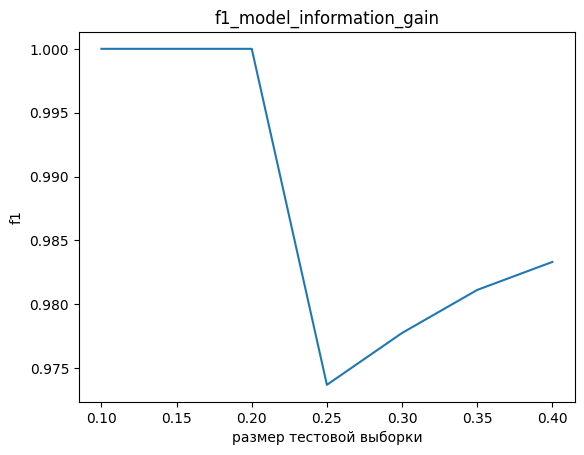

In [31]:
f1_model_information_gain = []

from sklearn.metrics import f1_score

for sz in size:
  X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=sz, random_state=42)
  y_pred = model_information_gain.fit(X_train, y_train).predict(X_test)
  f1_model_information_gain.append(f1_score(y_test, y_pred, average='weighted'))

import matplotlib.pyplot as plot
plot.plot(size, f1_model_information_gain)
plot.title("f1_model_information_gain")
plot.xlabel("размер тестовой выборки")
plot.ylabel("f1")
plot.show()

In [32]:
from sklearn.metrics import classification_report

# Оценка производительности модели
for trees in tree_gain:
  y_pred_info = trees.predict(X_test)
  print("Classification Report tree")
  print(classification_report(y_test, y_pred_info))

Classification Report tree
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      1.00      1.00         6
           2       1.00      1.00      1.00         3

    accuracy                           1.00        15
   macro avg       1.00      1.00      1.00        15
weighted avg       1.00      1.00      1.00        15

Classification Report tree
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      1.00      1.00         6
           2       1.00      1.00      1.00         3

    accuracy                           1.00        15
   macro avg       1.00      1.00      1.00        15
weighted avg       1.00      1.00      1.00        15

Classification Report tree
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      1.00      1.00     

[Text(0.5, 0.9166666666666666, 'x[3] <= 0.8\nentropy = 1.584\nsamples = 135\nvalue = [44, 44, 47]'), Text(0.4230769230769231, 0.75, 'entropy = 0.0\nsamples = 44\nvalue = [44, 0, 0]'), Text(0.46153846153846156, 0.8333333333333333, 'True  '), Text(0.5769230769230769, 0.75, 'x[3] <= 1.75\nentropy = 0.999\nsamples = 91\nvalue = [0.0, 44.0, 47.0]'), Text(0.5384615384615384, 0.8333333333333333, '  False'), Text(0.3076923076923077, 0.5833333333333334, 'x[2] <= 4.95\nentropy = 0.482\nsamples = 48\nvalue = [0, 43, 5]'), Text(0.15384615384615385, 0.4166666666666667, 'x[3] <= 1.65\nentropy = 0.162\nsamples = 42\nvalue = [0, 41, 1]'), Text(0.07692307692307693, 0.25, 'entropy = 0.0\nsamples = 41\nvalue = [0, 41, 0]'), Text(0.23076923076923078, 0.25, 'entropy = 0.0\nsamples = 1\nvalue = [0, 0, 1]'), Text(0.46153846153846156, 0.4166666666666667, 'x[3] <= 1.55\nentropy = 0.918\nsamples = 6\nvalue = [0, 2, 4]'), Text(0.38461538461538464, 0.25, 'entropy = 0.0\nsamples = 3\nvalue = [0, 0, 3]'), Text(0.53

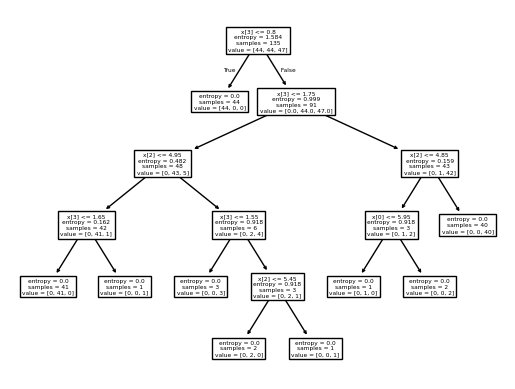

In [33]:
for trees in tree_gain:
  print(tree.plot_tree(trees))